In [3]:
from src.dataloading import DeepDataLoader, EpiDataLoader
from src.utils import get_data_env

modelname       = 'gatv2model'
disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lags            = 1


# training hparams
n_epochs        = 200
lr              = 0.000005
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

model_hparams = {
    'hidden_size' : 256,
    'num_layers' : 3,           # spatial
    'temporal_layers' : 4,      # time
    'num_heads' : 4
}

epiloader = EpiDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epiloader.add_time_features()
epiloader.log_transform_target()
epiloader.set_splits(split_trainval, split_valtest)
epiloader.normalize()
epiloader.add_lagged_features(lags = lags)
epiloader.finalize()

epidata_loader_basis = DeepDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed


EpiDataLoader(disease=influenza, nuts_level=nuts3, min_date=2006-04-17, max_date=2020-06-01, horizon_size=1, horizon_leadtime=3, sequence_length=1)

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))

==     Training gatv2 bn graph     ==
Epoch 1 train loss: 0.9711, val loss: 2.3617 ✓ (new best)
Epoch 2 train loss: 0.9281, val loss: 2.1240 ✓ (new best)
Epoch 3 train loss: 0.8970, val loss: 1.9018 ✓ (new best)
Epoch 4 train loss: 0.8637, val loss: 1.7224 ✓ (new best)
Epoch 5 train loss: 0.8324, val loss: 1.5839 ✓ (new best)
Epoch 6 train loss: 0.8115, val loss: 1.4818 ✓ (new best)
Epoch 7 t

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 385.58it/s]


Test loss: 0.8799
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 1754), edge_weight=(1754,))

==     Training gatv2 cm1 graph     ==
Epoch 1 train loss: 0.9812, val loss: 2.3559 ✓ (new best)
Epoch 2 train loss: 0.9285, val loss: 2.1278 ✓ (new best)
Epoch 3 train loss: 0.8914, val loss: 1.9393 ✓ (new best)
Epoch 4 train loss: 0.8595, val loss: 1.7809 ✓ (new best)
Epoch 5 train loss: 0.8252, val loss: 1.6338 ✓ (new best)
Epoch 6 train loss: 0.8006, val loss: 1.5265 ✓ (new best)
Epoch 7 train loss: 0.7769, val loss: 1.4328 ✓ (new best)
Epoch 8 train loss: 0.7479, val loss: 1.3576 ✓ (new best)
Epoch 9 train loss: 0.7221, val loss: 1.2839 ✓ (new best)
Epoch 10 train loss: 0.6981, val loss: 1.2121 ✓ (new best)
Epoch 11 train loss: 0.6744, val loss: 1.1476 ✓ (new best)
Epoch 12 train loss: 0.6580, val loss: 1.0828 ✓ (new best)
Epoch 13 train loss: 0.6434, val loss: 1.0280 ✓ (new best)
Epoch 14 train loss: 0.6318, val loss: 0.9749 ✓ (new best)
Epoch 15 trai

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 387.82it/s]


Test loss: 0.8601
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 1754), edge_weight=(1754,))

==     Training gatv2 cm2 graph     ==
Epoch 1 train loss: 0.9845, val loss: 2.3494 ✓ (new best)
Epoch 2 train loss: 0.9316, val loss: 2.0220 ✓ (new best)
Epoch 3 train loss: 0.9052, val loss: 1.8638 ✓ (new best)
Epoch 4 train loss: 0.8792, val loss: 1.7426 ✓ (new best)
Epoch 5 train loss: 0.8469, val loss: 1.6257 ✓ (new best)
Epoch 6 train loss: 0.8194, val loss: 1.5297 ✓ (new best)
Epoch 7 train loss: 0.7948, val loss: 1.4488 ✓ (new best)
Epoch 8 train loss: 0.7693, val loss: 1.3785 ✓ (new best)
Epoch 9 train loss: 0.7407, val loss: 1.3109 ✓ (new best)
Epoch 10 train loss: 0.7121, val loss: 1.2464 ✓ (new best)
Epoch 11 train loss: 0.6873, val loss: 1.1886 ✓ (new best)
Epoch 12 train loss: 0.6703, val loss: 1.1329 ✓ (new best)
Epoch 13 train loss: 0.6550, val loss: 1.0716 ✓ (new best)
Epoch 14 train loss: 0.6396, val loss: 1.0212 ✓ (new best)
Epoch 15 trai

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 384.62it/s]


Test loss: 0.8485
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))

==     Training gatv2 id graph     ==
Epoch 1 train loss: 0.9801, val loss: 2.3674 ✓ (new best)
Epoch 2 train loss: 0.9241, val loss: 2.1231 ✓ (new best)
Epoch 3 train loss: 0.8857, val loss: 1.8911 ✓ (new best)
Epoch 4 train loss: 0.8536, val loss: 1.7086 ✓ (new best)
Epoch 5 train loss: 0.8233, val loss: 1.5675 ✓ (new best)
Epoch 6 train loss: 0.8013, val loss: 1.4649 ✓ (new best)
Epoch 7 train loss: 0.7746, val loss: 1.3844 ✓ (new best)
Epoch 8 train loss: 0.7431, val loss: 1.3250 ✓ (new best)
Epoch 9 train loss: 0.7167, val loss: 1.2612 ✓ (new best)
Epoch 10 train loss: 0.6885, val loss: 1.2057 ✓ (new best)
Epoch 11 train loss: 0.6668, val loss: 1.1536 ✓ (new best)
Epoch 12 train loss: 0.6482, val loss: 1.1013 ✓ (new best)
Epoch 13 train loss: 0.6330, val loss: 1.0543 ✓ (new best)
Epoch 14 train loss: 0.6218, val loss: 1.0126 ✓ (new best)
Epoch 15 train l

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 213.75it/s]

Test loss: 0.9308


PersistenceModel(name='persistence baseline')

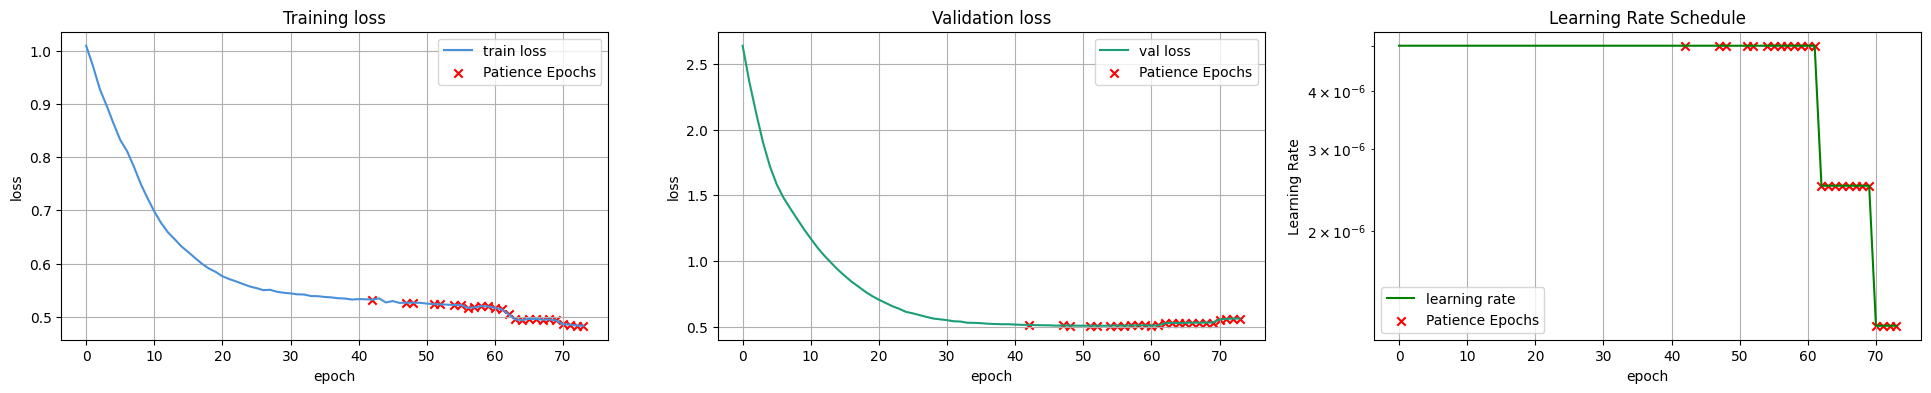

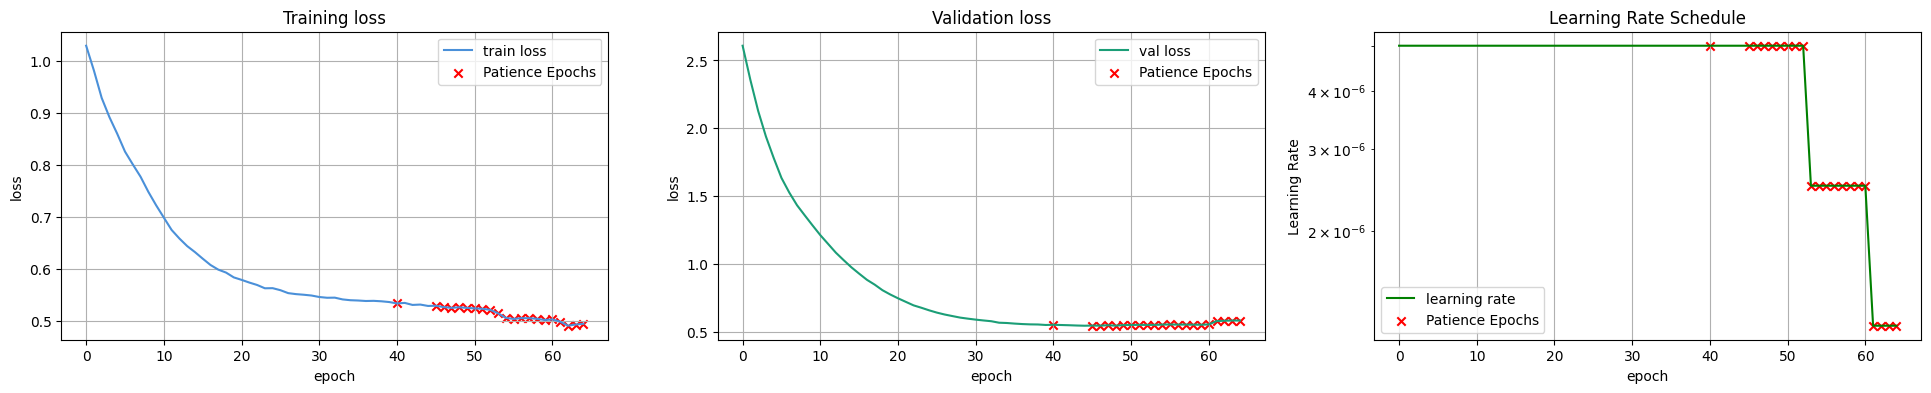

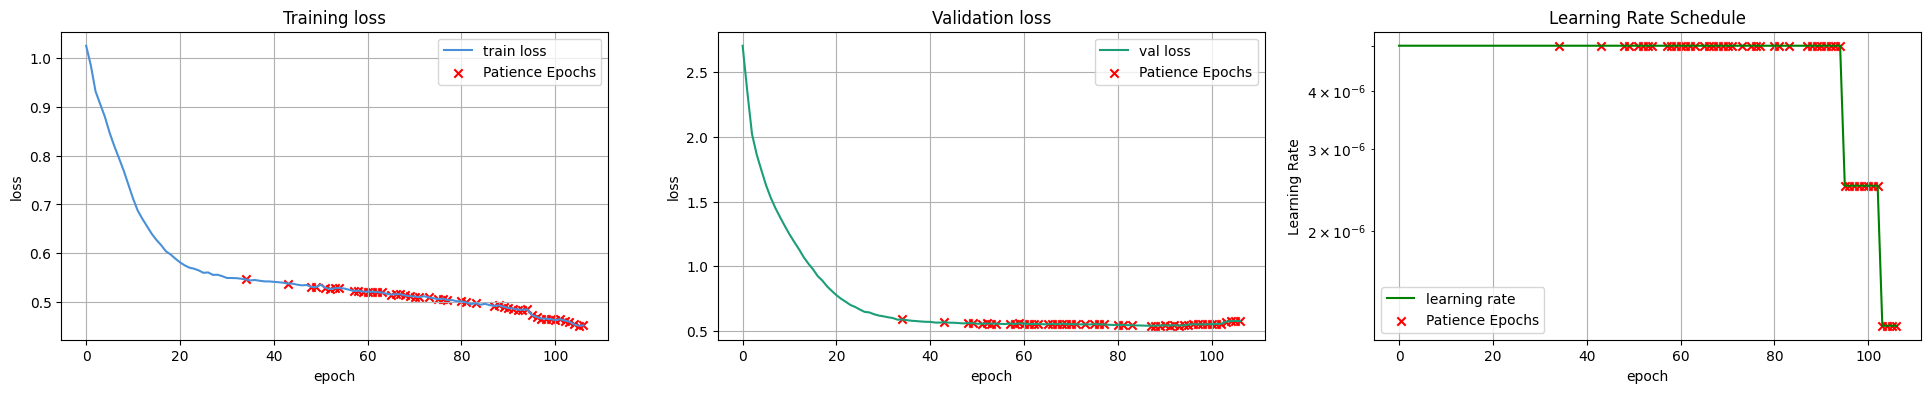

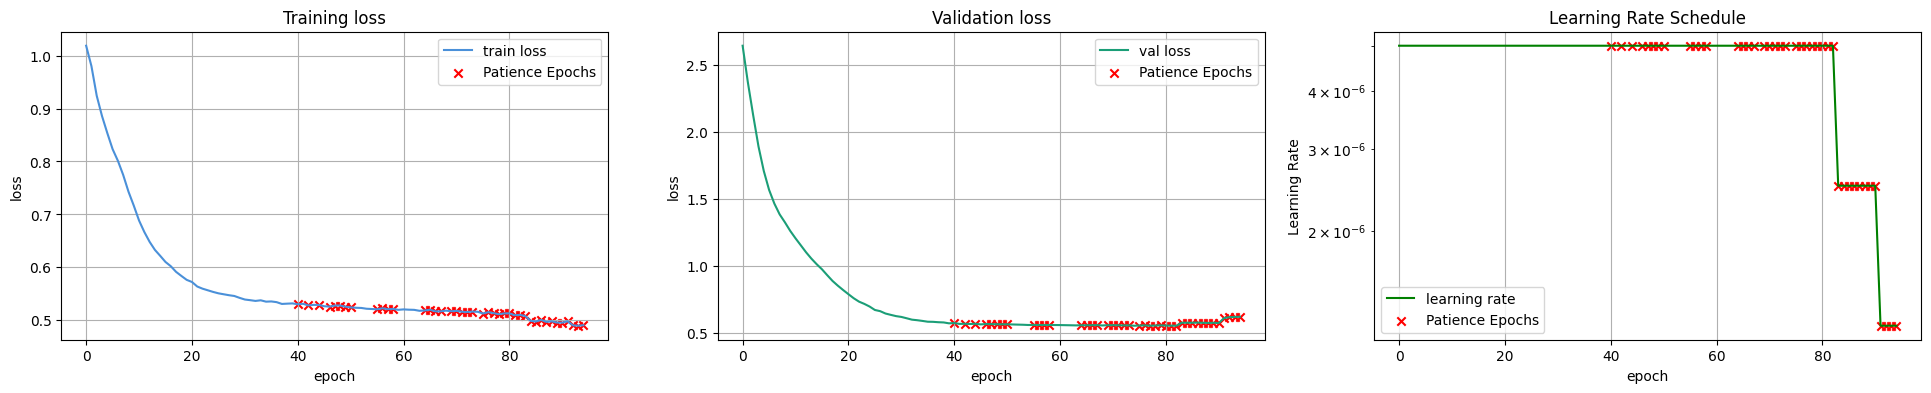

In [4]:
from src.models.deep.gatv2 import GATv2Model
from src.models.base.persistencemodel import PersistenceModel

dl_id  = epidata_loader_basis.copy().retrieve_graph('identity_selfmax').construct_dataloaders()
dl_bn  = epidata_loader_basis.copy().retrieve_graph('boolean_neighbors_selfmean').construct_dataloaders()
dl_cm1 = epidata_loader_basis.copy().retrieve_graph('commuter_t2000_selfmean_symmetric').construct_dataloaders()
dl_cm2 = epidata_loader_basis.copy().retrieve_graph('commuter_t2000_selfmean_rowwise').construct_dataloaders()

gatv2_bn = GATv2Model(dataloader= dl_bn, name = 'gatv2 bn graph')
gatv2_bn.set_model_hparams(**model_hparams)
gatv2_bn.set_global_hparams(**global_hparams)
gatv2_bn.train(2)
gatv2_bn.forecast('test')

gatv2_cm1 = GATv2Model(dataloader= dl_cm1, name = 'gatv2 cm1 graph')
gatv2_cm1.set_model_hparams(**model_hparams)
gatv2_cm1.set_global_hparams(**global_hparams)
gatv2_cm1.train(2)
gatv2_cm1.forecast('test')

gatv2_cm2 = GATv2Model(dataloader= dl_cm2, name = 'gatv2 cm2 graph')
gatv2_cm2.set_model_hparams(**model_hparams)
gatv2_cm2.set_global_hparams(**global_hparams)
gatv2_cm2.train(2)
gatv2_cm2.forecast('test')

gatv2_id = GATv2Model(dataloader= dl_id, name = 'gatv2 id graph')
gatv2_id.set_model_hparams(**model_hparams)
gatv2_id.set_global_hparams(**global_hparams)
gatv2_id.train(2)
gatv2_id.forecast('test')

baseline = PersistenceModel(epiloader, name = 'persistence baseline')
baseline.forecast('test')